# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HassaanSaqib/FlyRankAI-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

My validated output is converted into a **human-review queue**, not an automatic publishing system.

The model estimates a directional decline-risk score from measurements available before the latest 30-day outcome window. I then combine that score with a simple value-and-effort layer:

- **Risk:** the strict pre-outcome model score.

- **Value:** previous-window search visibility, represented by impressions.

- **Effort:** a lightweight review-cost estimate based on available word count.

- **Priority:** risk × value, adjusted by estimated review effort.

The priority score is a transparent queueing heuristic. It is not a probability of business impact and does not prove that refreshing a page will improve performance.

### Archetype-to-action mapping

| Archetype | Suggested action |

|---|---|

| High risk + stale | `REFRESH_REVIEW` |

| High risk + visible but weak CTR | `METADATA_REVIEW` |

| High risk + limited visibility | `DIAGNOSE_FIRST` |

| Medium risk + meaningful visibility | `MONITOR_AND_REVIEW` |

| Low risk + strong visibility | `PROTECT_AND_MONITOR` |

| Insufficient measurement history | `DATA_QUALITY_REVIEW` |

Each recommendation includes human-readable reason codes so a reviewer can understand why the page entered the queue.

The decay analysis is descriptive only. It compares observed decline rates across freshness groups, but it does not establish that age or staleness causes decline.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from pathlib import Path

import json

import subprocess

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import GroupShuffleSplit

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    average_precision_score,

    roc_auc_score,

)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ------------------------------------------------------------

# 1A. Load the anonymised starter dataset

# ------------------------------------------------------------

REPO_URL = (

    "https://github.com/HassaanSaqib/"

    "FlyRankAI-Internship.git"

)

REPO_DIR = Path("/content/flyrank_w07_repo")

DATA_PATH = (

    REPO_DIR

    / "data"

    / "raw"

    / "content_refresh_anonymized.csv"

)

if not REPO_DIR.exists():

    subprocess.run(

        [

            "git",

            "clone",

            "-q",

            REPO_URL,

            str(REPO_DIR),

        ],

        check=True,

    )

else:

    subprocess.run(

        [

            "git",

            "-C",

            str(REPO_DIR),

            "pull",

            "-q",

        ],

        check=False,

    )

if not DATA_PATH.exists():

    raise FileNotFoundError(

        f"Dataset was not found at {DATA_PATH}"

    )

df = pd.read_csv(DATA_PATH)

required_columns = {

    "content_id",

    "client_id",

    "trend_direction",

    "impressions_prev_30d",

    "clicks_prev_30d",

    "sessions_prev_30d",

    "impressions_90d",

    "ctr",

    "avg_position",

    "days_since_last_update",

    "content_age_days",

    "word_count",

}

missing_columns = required_columns.difference(

    df.columns

)

if missing_columns:

    raise KeyError(

        "Required columns are missing: "

        f"{sorted(missing_columns)}"

    )

numeric_columns = sorted(

    required_columns

    - {

        "content_id",

        "client_id",

        "trend_direction",

    }

)

for column in numeric_columns:

    df[column] = pd.to_numeric(

        df[column],

        errors="coerce",

    )

# Retrospective evaluation label.

df["is_declining_eval"] = (

    df["trend_direction"]

    .astype(str)

    .str.lower()

    .eq("down")

    .astype(int)

)

# ------------------------------------------------------------

# 1B. Strict pre-outcome features from Week 6

# ------------------------------------------------------------

df["log_impressions_prev_30d"] = np.log1p(

    df["impressions_prev_30d"].clip(lower=0)

)

df["log_clicks_prev_30d"] = np.log1p(

    df["clicks_prev_30d"].clip(lower=0)

)

df["log_sessions_prev_30d"] = np.log1p(

    df["sessions_prev_30d"].clip(lower=0)

)

df["ctr_prev_30d"] = np.where(

    df["impressions_prev_30d"] > 0,

    (

        100

        * df["clicks_prev_30d"]

        / df["impressions_prev_30d"]

    ),

    np.nan,

)

df[

    "sessions_per_100_impressions_prev_30d"

] = np.where(

    df["impressions_prev_30d"] > 0,

    (

        100

        * df["sessions_prev_30d"]

        / df["impressions_prev_30d"]

    ),

    np.nan,

)

df["has_prev_impressions"] = (

    df["impressions_prev_30d"]

    .gt(0)

    .astype(int)

)

df["has_prev_clicks"] = (

    df["clicks_prev_30d"]

    .gt(0)

    .astype(int)

)

df["has_prev_sessions"] = (

    df["sessions_prev_30d"]

    .gt(0)

    .astype(int)

)

safe_feature_columns = [

    "log_impressions_prev_30d",

    "log_clicks_prev_30d",

    "log_sessions_prev_30d",

    "ctr_prev_30d",

    "sessions_per_100_impressions_prev_30d",

    "has_prev_impressions",

    "has_prev_clicks",

    "has_prev_sessions",

]

forbidden_features = {

    "content_id",

    "client_id",

    "trend_direction",

    "trend_pct",

    "is_declining_eval",

    "is_declining_label",

    "baseline_score",

    "action_label",

    "reason_code",

}

assert not set(

    safe_feature_columns

).intersection(forbidden_features)

X = df[safe_feature_columns].copy()

y = df["is_declining_eval"].astype(int)

groups = (

    df["client_id"]

    .fillna("unknown")

    .astype(str)

)

# ------------------------------------------------------------

# 1C. Honest grouped validation split

# ------------------------------------------------------------

splitter = GroupShuffleSplit(

    n_splits=20,

    test_size=0.20,

    random_state=RANDOM_STATE,

)

valid_split = None

for candidate_train, candidate_test in splitter.split(

    X,

    y,

    groups,

):

    train_classes = y.iloc[

        candidate_train

    ].nunique()

    test_classes = y.iloc[

        candidate_test

    ].nunique()

    if train_classes == 2 and test_classes == 2:

        valid_split = (

            np.asarray(candidate_train),

            np.asarray(candidate_test),

        )

        break

if valid_split is None:

    raise ValueError(

        "A valid grouped split could not be created."

    )

train_idx, test_idx = valid_split

train_clients = set(groups.iloc[train_idx])

test_clients = set(groups.iloc[test_idx])

assert not train_clients.intersection(

    test_clients

), "Client leakage detected."

# ------------------------------------------------------------

# 1D. Candidate models and ranking metrics

# ------------------------------------------------------------

def build_model(model_name):

    if model_name == "Logistic Regression":

        return Pipeline(

            steps=[

                (

                    "imputer",

                    SimpleImputer(

                        strategy="median"

                    ),

                ),

                (

                    "scaler",

                    StandardScaler(),

                ),

                (

                    "model",

                    LogisticRegression(

                        class_weight="balanced",

                        max_iter=2000,

                        random_state=RANDOM_STATE,

                    ),

                ),

            ]

        )

    if model_name == "Random Forest":

        return Pipeline(

            steps=[

                (

                    "imputer",

                    SimpleImputer(

                        strategy="median"

                    ),

                ),

                (

                    "model",

                    RandomForestClassifier(

                        n_estimators=300,

                        max_depth=8,

                        min_samples_leaf=25,

                        class_weight=(

                            "balanced_subsample"

                        ),

                        random_state=RANDOM_STATE,

                        n_jobs=-1,

                    ),

                ),

            ]

        )

    raise ValueError(

        f"Unknown model: {model_name}"

    )

def precision_at_k(y_true, scores, k):

    ranked = pd.DataFrame(

        {

            "target": np.asarray(

                y_true,

                dtype=int,

            ),

            "score": np.asarray(

                scores,

                dtype=float,

            ),

        }

    ).sort_values(

        "score",

        ascending=False,

        kind="mergesort",

    )

    top_k = ranked.head(

        min(k, len(ranked))

    )

    if top_k.empty:

        return 0.0

    return float(

        top_k["target"].mean()

    )

def evaluate_ranking(y_true, scores):

    y_array = np.asarray(

        y_true,

        dtype=int,

    )

    score_array = np.asarray(

        scores,

        dtype=float,

    )

    return {

        "base_rate": float(

            y_array.mean()

        ),

        "precision_at_20": precision_at_k(

            y_array,

            score_array,

            20,

        ),

        "precision_at_50": precision_at_k(

            y_array,

            score_array,

            50,

        ),

        "average_precision": float(

            average_precision_score(

                y_array,

                score_array,

            )

        ),

        "roc_auc": float(

            roc_auc_score(

                y_array,

                score_array,

            )

        ),

    }

candidate_names = [

    "Logistic Regression",

    "Random Forest",

]

validation_rows = []

fitted_candidates = {}

for model_name in candidate_names:

    model = build_model(model_name)

    model.fit(

        X.iloc[train_idx],

        y.iloc[train_idx],

    )

    test_scores = model.predict_proba(

        X.iloc[test_idx]

    )[:, 1]

    metrics = evaluate_ranking(

        y.iloc[test_idx],

        test_scores,

    )

    validation_rows.append(

        {

            "Model": model_name,

            **metrics,

        }

    )

    fitted_candidates[model_name] = model

validation_table = (

    pd.DataFrame(validation_rows)

    .sort_values(

        [

            "precision_at_20",

            "average_precision",

        ],

        ascending=False,

    )

    .reset_index(drop=True)

)

selected_model_name = validation_table.iloc[

    0

]["Model"]

display(

    Markdown(

        "### Grouped validation result"

    )

)

display(

    validation_table.style.format(

        {

            "base_rate": "{:.1%}",

            "precision_at_20": "{:.1%}",

            "precision_at_50": "{:.1%}",

            "average_precision": "{:.3f}",

            "roc_auc": "{:.3f}",

        }

    )

)

# ------------------------------------------------------------

# 1E. Refit selected model on all rows for queue generation

# ------------------------------------------------------------

# The grouped holdout above provides the evaluation.

# Re-fitting on all available rows is used only to generate

# the practical portfolio queue after model selection.

final_model = build_model(

    selected_model_name

)

final_model.fit(X, y)

df["model_risk_score"] = (

    final_model.predict_proba(X)[:, 1]

)

# ------------------------------------------------------------

# 1F. Value, effort and priority

# ------------------------------------------------------------

visibility_log = np.log1p(

    df["impressions_prev_30d"]

    .fillna(0)

    .clip(lower=0)

)

visibility_min = visibility_log.min()

visibility_max = visibility_log.max()

if visibility_max > visibility_min:

    df["value_score"] = (

        visibility_log - visibility_min

    ) / (

        visibility_max - visibility_min

    )

else:

    df["value_score"] = 0.0

# Cost is deliberately lightweight and operational.

# It is not learned by the model.

df["review_effort"] = pd.cut(

    df["word_count"],

    bins=[

        -np.inf,

        800,

        1800,

        np.inf,

    ],

    labels=[

        "LOW",

        "MEDIUM",

        "HIGH",

    ],

).astype("object")

df["review_effort"] = (

    df["review_effort"]

    .fillna("UNKNOWN")

)

effort_points = {

    "LOW": 1.0,

    "MEDIUM": 2.0,

    "HIGH": 3.0,

    "UNKNOWN": 2.0,

}

df["effort_points"] = (

    df["review_effort"]

    .map(effort_points)

    .astype(float)

)

df["priority_score"] = (

    df["model_risk_score"]

    * (

        0.25

        + 0.75 * df["value_score"]

    )

    / df["effort_points"]

)

# ------------------------------------------------------------

# 1G. Operational review signals

# ------------------------------------------------------------

valid_position = df["avg_position"].where(

    df["avg_position"] > 0,

    np.nan,

)

position_bucket = pd.cut(

    valid_position,

    bins=[

        0,

        3,

        10,

        20,

        50,

        np.inf,

    ],

    labels=[

        "TOP_3",

        "PAGE_1",

        "STRIKING_DISTANCE",

        "PAGE_3_5",

        "DEEP",

    ],

)

df["position_bucket"] = (

    position_bucket

    .astype("object")

    .fillna("NO_POSITION_DATA")

)

eligible_ctr_reference = (

    df["impressions_90d"].ge(300)

    & valid_position.notna()

)

position_ctr_reference = (

    df.loc[eligible_ctr_reference]

    .groupby(

        "position_bucket",

        observed=False,

    )["ctr"]

    .median()

    .to_dict()

)

global_ctr_reference = float(

    df.loc[

        eligible_ctr_reference,

        "ctr",

    ].median()

)

if not np.isfinite(global_ctr_reference):

    global_ctr_reference = 0.0

df["expected_ctr_for_position"] = (

    df["position_bucket"]

    .map(position_ctr_reference)

    .astype(float)

    .fillna(global_ctr_reference)

)

df["stale_signal"] = (

    df["days_since_last_update"]

    .fillna(-1)

    .ge(180)

)

df["low_ctr_signal"] = (

    eligible_ctr_reference

    & df["expected_ctr_for_position"].gt(0)

    & df["ctr"].le(

        0.80

        * df["expected_ctr_for_position"]

    )

)

df["limited_history_signal"] = (

    df["impressions_prev_30d"].isna()

    | df["clicks_prev_30d"].isna()

    | df["sessions_prev_30d"].isna()

)

df["strong_visibility_signal"] = (

    df["impressions_prev_30d"]

    .fillna(0)

    .ge(

        df["impressions_prev_30d"]

        .quantile(0.75)

    )

)

# Risk bands are relative to this dataset.

risk_high_threshold = float(

    df["model_risk_score"].quantile(0.80)

)

risk_medium_threshold = float(

    df["model_risk_score"].quantile(0.50)

)

df["risk_band"] = np.select(

    [

        df["model_risk_score"].ge(

            risk_high_threshold

        ),

        df["model_risk_score"].ge(

            risk_medium_threshold

        ),

    ],

    [

        "HIGH",

        "MEDIUM",

    ],

    default="LOW",

)

# ------------------------------------------------------------

# 1H. Archetype-to-action mapping

# ------------------------------------------------------------

conditions = [

    df["limited_history_signal"],

    (

        df["risk_band"].eq("HIGH")

        & df["stale_signal"]

    ),

    (

        df["risk_band"].eq("HIGH")

        & df["low_ctr_signal"]

        & valid_position.le(20)

    ),

    (

        df["risk_band"].eq("HIGH")

        & ~df["strong_visibility_signal"]

    ),

    (

        df["risk_band"].eq("MEDIUM")

        & df["value_score"].ge(0.40)

    ),

    (

        df["risk_band"].eq("LOW")

        & df["strong_visibility_signal"]

    ),

]

actions = [

    "DATA_QUALITY_REVIEW",

    "REFRESH_REVIEW",

    "METADATA_REVIEW",

    "DIAGNOSE_FIRST",

    "MONITOR_AND_REVIEW",

    "PROTECT_AND_MONITOR",

]

df["recommended_action"] = np.select(

    conditions,

    actions,

    default="MONITOR",

)

archetype_map = {

    "DATA_QUALITY_REVIEW": (

        "Insufficient measurement history"

    ),

    "REFRESH_REVIEW": (

        "High observed risk + stale"

    ),

    "METADATA_REVIEW": (

        "High observed risk + visible + weak CTR"

    ),

    "DIAGNOSE_FIRST": (

        "High observed risk + limited visibility"

    ),

    "MONITOR_AND_REVIEW": (

        "Medium observed risk + meaningful value"

    ),

    "PROTECT_AND_MONITOR": (

        "Low observed risk + strong visibility"

    ),

    "MONITOR": (

        "No urgent review pattern"

    ),

}

df["archetype"] = (

    df["recommended_action"]

    .map(archetype_map)

)

# ------------------------------------------------------------

# 1I. Human-readable reason codes

# ------------------------------------------------------------

def make_reason_codes(row):

    reasons = []

    if row["risk_band"] == "HIGH":

        reasons.append("HIGH_MODEL_RISK")

    elif row["risk_band"] == "MEDIUM":

        reasons.append("MEDIUM_MODEL_RISK")

    else:

        reasons.append("LOW_MODEL_RISK")

    if row["stale_signal"]:

        reasons.append("STALE_180D_PLUS")

    if row["low_ctr_signal"]:

        reasons.append("CTR_BELOW_POSITION_REFERENCE")

    if row["strong_visibility_signal"]:

        reasons.append("HIGH_PREVIOUS_VISIBILITY")

    if row["limited_history_signal"]:

        reasons.append("LIMITED_MEASUREMENT_HISTORY")

    if row["review_effort"] == "HIGH":

        reasons.append("HIGH_REVIEW_EFFORT")

    elif row["review_effort"] == "LOW":

        reasons.append("LOW_REVIEW_EFFORT")

    return "|".join(reasons)

df["reason_codes"] = df.apply(

    make_reason_codes,

    axis=1,

)

# ------------------------------------------------------------

# 1J. Build public-safe ranked queue

# ------------------------------------------------------------

ranked_queue = (

    df[

        [

            "content_id",

            "recommended_action",

            "archetype",

            "reason_codes",

            "risk_band",

            "model_risk_score",

            "value_score",

            "review_effort",

            "priority_score",

            "impressions_prev_30d",

            "ctr_prev_30d",

            "avg_position",

            "days_since_last_update",

        ]

    ]

    .sort_values(

        [

            "priority_score",

            "model_risk_score",

        ],

        ascending=False,

    )

    .reset_index(drop=True)

)

ranked_queue.insert(

    0,

    "queue_rank",

    np.arange(

        1,

        len(ranked_queue) + 1,

    ),

)

display(

    Markdown(

        "### Top 20 human-review recommendations"

    )

)

display(

    ranked_queue.head(20).style.format(

        {

            "model_risk_score": "{:.3f}",

            "value_score": "{:.3f}",

            "priority_score": "{:.3f}",

            "impressions_prev_30d": "{:,.0f}",

            "ctr_prev_30d": "{:.2f}%",

            "avg_position": "{:.1f}",

            "days_since_last_update": "{:.0f}",

        }

    )

)

action_summary = (

    ranked_queue[

        "recommended_action"

    ]

    .value_counts()

    .rename_axis(

        "recommended_action"

    )

    .reset_index(name="pages")

)

display(

    Markdown(

        "### Queue action summary"

    )

)

display(action_summary)

# ------------------------------------------------------------

# 1K. Descriptive decay/refresh insight

# ------------------------------------------------------------

df["freshness_group"] = pd.cut(

    df["days_since_last_update"],

    bins=[

        -np.inf,

        90,

        180,

        365,

        np.inf,

    ],

    labels=[

        "0–90 days",

        "91–180 days",

        "181–365 days",

        "366+ days",

    ],

)

decay_refresh_insight = (

    df.groupby(

        "freshness_group",

        observed=False,

    )

    .agg(

        pages=(

            "is_declining_eval",

            "size",

        ),

        observed_decline_rate=(

            "is_declining_eval",

            "mean",

        ),

        median_impressions_prev_30d=(

            "impressions_prev_30d",

            "median",

        ),

    )

    .reset_index()

)

display(

    Markdown(

        "### Descriptive freshness/decline comparison"

    )

)

display(

    decay_refresh_insight.style.format(

        {

            "pages": "{:,.0f}",

            "observed_decline_rate": "{:.1%}",

            "median_impressions_prev_30d": "{:,.0f}",

        }

    )

)

print("Ranked queue created.")

print(f"Selected model: {selected_model_name}")

print("Client overlap in validation split: 0")

### Grouped validation result

,Model,base_rate,precision_at_20,precision_at_50,average_precision,roc_auc
0,Random Forest,51.1%,70.0%,68.0%,0.597,0.637
1,Logistic Regression,51.1%,65.0%,64.0%,0.594,0.626


### Top 20 human-review recommendations

,queue_rank,content_id,recommended_action,archetype,reason_codes,risk_band,model_risk_score,value_score,review_effort,priority_score,impressions_prev_30d,ctr_prev_30d,avg_position,days_since_last_update
0,1,content_c8e9d6ab9013,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.794,0.945,UNKNOWN,0.381,"111,885",0.00%,9.7,104
1,2,content_65114d89496d,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.796,0.886,UNKNOWN,0.364,"54,088",0.01%,6.5,22
2,3,content_7a35909752a1,MONITOR_AND_REVIEW,Medium observed risk + meaningful value,MEDIUM_MODEL_RISK|LOW_REVIEW_EFFORT,MEDIUM,0.617,0.421,LOW,0.349,177,0.56%,5.8,20
3,4,content_d07ea098353c,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.755,0.869,UNKNOWN,0.340,"43,925",0.02%,9.4,104
4,5,content_b49efa4db88a,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.791,0.803,MEDIUM,0.337,"19,440",0.02%,4.6,40
5,6,content_d274ac4158ef,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.781,0.816,MEDIUM,0.336,"22,650",0.01%,6.8,26
6,7,content_b80d73524f2d,MONITOR,No urgent review pattern,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.806,0.766,MEDIUM,0.332,"12,366",0.00%,44.0,104
7,8,content_aee336a1d75a,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.789,0.789,UNKNOWN,0.332,"16,275",0.02%,5.7,22
8,9,content_aa8a54a50d71,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.785,0.789,UNKNOWN,0.330,"16,284",0.01%,8.2,104
9,10,content_609902f4bc8c,METADATA_REVIEW,High observed risk + visible + weak CTR,HIGH_MODEL_RISK|CTR_BELOW_POSITION_REFERENCE|HIGH_PREVIOUS_VISIBILITY,HIGH,0.788,0.779,UNKNOWN,0.329,"14,416",0.03%,6.4,34


### Queue action summary

,recommended_action,pages
0,MONITOR,16230
1,MONITOR_AND_REVIEW,4617
2,PROTECT_AND_MONITOR,4127
3,DIAGNOSE_FIRST,2540
4,METADATA_REVIEW,2475
5,REFRESH_REVIEW,11


### Descriptive freshness/decline comparison

,freshness_group,pages,observed_decline_rate,median_impressions_prev_30d
0,0–90 days,"20,655",51.2%,128
1,91–180 days,"9,171",61.1%,492
2,181–365 days,169,46.7%,5
3,366+ days,5,60.0%,2


Ranked queue created.
Selected model: Random Forest
Client overlap in validation split: 0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

This playbook is intended for a content strategist, SEO analyst or editor who needs to decide which anonymized pages deserve review first.

The queue can support:

- weekly or monthly review planning;

- identifying high-risk, high-value pages;

- separating refresh candidates from metadata-review candidates;

- identifying pages that require diagnosis before editing;

- protecting strong pages from unnecessary changes;

- documenting why each page was recommended.

### Where the output remains valid

The result is limited to:

- the supplied anonymized FlyRank starter dataset;

- its retrospective decline-label definition;

- its available measurement windows;

- the observed clients and content represented in the release;

- the grouped validation design used in this notebook.

The grouped holdout provides a more defensible estimate than a random row split, but it does not guarantee identical performance on every future client or time period.

### Important limitations

The score is not:

- a prediction of Google’s algorithm;

- proof that stale content causes decline;

- proof that refreshing a selected page will improve traffic;

- an estimate of revenue or business impact;

- a replacement for editorial, technical SEO or brand review;

- a production deployment.

The queue should be interpreted as **directional decision support**. It identifies pages worth checking first based on measured patterns, but the recommended action may change after a human examines the page’s purpose, history and strategic value.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
intended_use_table = pd.DataFrame(

    [

        {

            "Area": "Primary user",

            "Playbook position": (

                "Content strategist, SEO analyst or editor"

            ),

        },

        {

            "Area": "Supported decision",

            "Playbook position": (

                "Which anonymised pages should be reviewed first"

            ),

        },

        {

            "Area": "Output type",

            "Playbook position": (

                "Ranked decision-support queue with reason codes"

            ),

        },

        {

            "Area": "Validation",

            "Playbook position": (

                "Grouped client holdout with zero overlap"

            ),

        },

        {

            "Area": "Automation status",

            "Playbook position": (

                "Non-production and human-reviewed"

            ),

        },

        {

            "Area": "Causal status",

            "Playbook position": (

                "No causal refresh claim"

            ),

        },

    ]

)

display(

    Markdown(

        "### Intended-use card"

    )

)

display(intended_use_table)

limits_table = pd.DataFrame(

    [

        {

            "Known limit": (

                "Retrospective label"

            ),

            "Practical response": (

                "Describe the result as observed and directional."

            ),

        },

        {

            "Known limit": (

                "Small anonymised portfolio"

            ),

            "Practical response": (

                "Do not assume identical performance elsewhere."

            ),

        },

        {

            "Known limit": (

                "No controlled refresh experiment"

            ),

            "Practical response": (

                "Do not claim that refresh causes improvement."

            ),

        },

        {

            "Known limit": (

                "Value is based on visibility proxy"

            ),

            "Practical response": (

                "Confirm business value before prioritising work."

            ),

        },

        {

            "Known limit": (

                "Effort estimate is coarse"

            ),

            "Practical response": (

                "An editor must replace it with a real work estimate."

            ),

        },

    ]

)

display(

    Markdown(

        "### Limits and responses"

    )

)

display(limits_table)

# Check that the public queue excludes direct client identifiers.

assert (

    "client_id"

    not in ranked_queue.columns

)

assert (

    "trend_direction"

    not in ranked_queue.columns

)

print("Public-safe queue check: PASS")

print("Direct client identifier exported: No")

print("Raw outcome label exported: No")

### Intended-use card

,Area,Playbook position
0,Primary user,"Content strategist, SEO analyst or editor"
1,Supported decision,Which anonymised pages should be reviewed first
2,Output type,Ranked decision-support queue with reason codes
3,Validation,Grouped client holdout with zero overlap
4,Automation status,Non-production and human-reviewed
5,Causal status,No causal refresh claim


### Limits and responses

,Known limit,Practical response
0,Retrospective label,Describe the result as observed and directional.
1,Small anonymised portfolio,Do not assume identical performance elsewhere.
2,No controlled refresh experiment,Do not claim that refresh causes improvement.
3,Value is based on visibility proxy,Confirm business value before prioritising work.
4,Effort estimate is coarse,An editor must replace it with a real work est...


Public-safe queue check: PASS
Direct client identifier exported: No
Raw outcome label exported: No


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every recommendation requires human review before action.

### Required review questions

The reviewer should confirm:

1. Is the page still strategically relevant?

2. Is the apparent decline real, or could tracking or seasonality explain it?

3. Has the page already been edited recently?

4. Does another page target the same intent?

5. Would rewriting create cannibalization or remove valuable material?

6. Does the page have backlinks, conversions or brand value not represented by the model?

7. Is the recommended action consistent with editorial and technical standards?

8. Is there enough measurement history to support any decision?

### Action-specific rules

- `REFRESH_REVIEW`: inspect factual accuracy, search intent, structure and outdated sections before changing anything.

- `METADATA_REVIEW`: examine title and description alignment, but do not change metadata using CTR alone.

- `DIAGNOSE_FIRST`: investigate indexing, tracking, content purpose and visibility before recommending a rewrite.

- `PROTECT_AND_MONITOR`: avoid unnecessary edits to a strong page.

- `DATA_QUALITY_REVIEW`: fix or investigate measurement quality before drawing a performance conclusion.

### No-go list: what must not be automated

The notebook must never automatically:

- publish, rewrite or delete content;

- change titles, descriptions, canonicals or redirects;

- merge or prune pages;

- declare a page successful or failed;

- infer Google’s algorithm;

- treat a model score as proof of causation;

- expose private queries, URLs, credentials or client information;

- act on pages with insufficient or unreliable measurements;

- optimise solely for the model score without editorial review.

The system ranks review candidates. A person remains responsible for deciding whether any action is appropriate.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
human_review_rules = pd.DataFrame(

    [

        {

            "Recommended action": "REFRESH_REVIEW",

            "Human must check": (

                "Accuracy, intent, outdated sections, "

                "seasonality and recent edit history"

            ),

            "Permitted automatic action": (

                "Place in review queue only"

            ),

        },

        {

            "Recommended action": "METADATA_REVIEW",

            "Human must check": (

                "SERP intent, title relevance, description "

                "quality and measurement reliability"

            ),

            "Permitted automatic action": (

                "Place in review queue only"

            ),

        },

        {

            "Recommended action": "DIAGNOSE_FIRST",

            "Human must check": (

                "Indexing, tracking, page purpose, visibility "

                "and possible cannibalisation"

            ),

            "Permitted automatic action": (

                "Create diagnostic flag only"

            ),

        },

        {

            "Recommended action": "MONITOR_AND_REVIEW",

            "Human must check": (

                "Whether the pattern persists in a later window"

            ),

            "Permitted automatic action": (

                "Schedule another measurement only"

            ),

        },

        {

            "Recommended action": "PROTECT_AND_MONITOR",

            "Human must check": (

                "Whether any proposed edit risks damaging "

                "a currently valuable page"

            ),

            "Permitted automatic action": (

                "Monitor measurements only"

            ),

        },

        {

            "Recommended action": "DATA_QUALITY_REVIEW",

            "Human must check": (

                "Missing, delayed or inconsistent measurement data"

            ),

            "Permitted automatic action": (

                "Flag missingness only"

            ),

        },

    ]

)

display(

    Markdown(

        "### Human-review rules"

    )

)

display(human_review_rules)

no_go_actions = [

    "Publish or rewrite page content",

    "Delete, merge or prune a page",

    "Change metadata, canonicals or redirects",

    "Infer or claim Google's ranking algorithm",

    "Treat the score as causal proof",

    "Expose client information or private search data",

    "Act where measurement history is insufficient",

    "Optimise solely for model score",

]

no_go_table = pd.DataFrame(

    {

        "Never automate": no_go_actions,

        "Reason": [

            (

                "Requires editorial and factual responsibility"

            ),

            (

                "Can cause irreversible traffic or content loss"

            ),

            (

                "Requires technical and strategic review"

            ),

            (

                "The model only measures patterns in one dataset"

            ),

            (

                "No controlled intervention established causality"

            ),

            (

                "Violates the public-safe data rule"

            ),

            (

                "The recommendation would not be evidence-supported"

            ),

            (

                "Business and reader value are broader than the score"

            ),

        ],

    }

)

display(

    Markdown(

        "### No-go list"

    )

)

display(no_go_table)

# Queue rows that must receive especially cautious review.

ranked_queue["manual_review_required"] = True

ranked_queue["review_warning"] = np.select(

    [

        ranked_queue[

            "recommended_action"

        ].eq("DATA_QUALITY_REVIEW"),

        ranked_queue[

            "review_effort"

        ].eq("UNKNOWN"),

        ranked_queue[

            "avg_position"

        ].fillna(0).le(0),

    ],

    [

        "CHECK_DATA_QUALITY_BEFORE_ACTION",

        "ESTIMATE_EDITORIAL_EFFORT",

        "CHECK_SEARCH_POSITION_AVAILABILITY",

    ],

    default="STANDARD_HUMAN_REVIEW",

)

assert ranked_queue[

    "manual_review_required"

].all()

print("Human review required for every queue row: PASS")

print("Automatic publishing actions included: No")

### Human-review rules

,Recommended action,Human must check,Permitted automatic action
0,REFRESH_REVIEW,"Accuracy, intent, outdated sections, seasonali...",Place in review queue only
1,METADATA_REVIEW,"SERP intent, title relevance, description qual...",Place in review queue only
2,DIAGNOSE_FIRST,"Indexing, tracking, page purpose, visibility a...",Create diagnostic flag only
3,MONITOR_AND_REVIEW,Whether the pattern persists in a later window,Schedule another measurement only
4,PROTECT_AND_MONITOR,Whether any proposed edit risks damaging a cur...,Monitor measurements only
5,DATA_QUALITY_REVIEW,"Missing, delayed or inconsistent measurement data",Flag missingness only


### No-go list

,Never automate,Reason
0,Publish or rewrite page content,Requires editorial and factual responsibility
1,"Delete, merge or prune a page",Can cause irreversible traffic or content loss
2,"Change metadata, canonicals or redirects",Requires technical and strategic review
3,Infer or claim Google's ranking algorithm,The model only measures patterns in one dataset
4,Treat the score as causal proof,No controlled intervention established causality
5,Expose client information or private search data,Violates the public-safe data rule
6,Act where measurement history is insufficient,The recommendation would not be evidence-suppo...
7,Optimise solely for model score,Business and reader value are broader than the...


Human review required for every queue row: PASS
Automatic publishing actions included: No


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This is a light monitoring plan for a portfolio project, not production infrastructure.

### What should be monitored

For each later evaluation window, record:

- grouped Precision@20;

- grouped average precision;

- held-out base rate;

- score distribution;

- proportion of pages assigned to each action;

- missingness in the strict feature set;

- number of new or previously unseen clients;

- human acceptance rate for reviewed recommendations.

Human acceptance means that a reviewer agreed the page deserved investigation. It does not mean the recommended edit caused an improvement.

### Review or retrain triggers

A review should be triggered when:

- Precision@20 drops by more than 20% relative to the validated reference;

- average precision approaches the outcome base rate;

- feature missingness increases by more than 10 percentage points;

- the high-risk share doubles or falls by half;

- more than 25% of scored pages come from previously unseen clients;

- the label definition or data pipeline changes;

- the measurement window changes;

- the model has not been reviewed for six months.

Retraining should happen only after confirming that the data contract, label timing and leakage controls remain valid. A metric drop should not automatically trigger deployment of a newly trained model.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
selected_validation_row = (

    validation_table[

        validation_table["Model"].eq(

            selected_model_name

        )

    ]

    .iloc[0]

)

monitoring_reference = {

    "selected_model": selected_model_name,

    "validation_design": (

        "grouped_client_holdout"

    ),

    "client_overlap": 0,

    "base_rate": float(

        selected_validation_row[

            "base_rate"

        ]

    ),

    "precision_at_20": float(

        selected_validation_row[

            "precision_at_20"

        ]

    ),

    "precision_at_50": float(

        selected_validation_row[

            "precision_at_50"

        ]

    ),

    "average_precision": float(

        selected_validation_row[

            "average_precision"

        ]

    ),

    "roc_auc": float(

        selected_validation_row[

            "roc_auc"

        ]

    ),

    "risk_high_threshold": float(

        risk_high_threshold

    ),

    "risk_medium_threshold": float(

        risk_medium_threshold

    ),

}

monitoring_plan = pd.DataFrame(

    [

        {

            "Signal": "Grouped Precision@20",

            "Reference": (

                monitoring_reference[

                    "precision_at_20"

                ]

            ),

            "Review trigger": (

                "Relative decline greater than 20%"

            ),

        },

        {

            "Signal": "Average precision",

            "Reference": (

                monitoring_reference[

                    "average_precision"

                ]

            ),

            "Review trigger": (

                "Approaches the held-out base rate"

            ),

        },

        {

            "Signal": "Feature missingness",

            "Reference": (

                "Current notebook run"

            ),

            "Review trigger": (

                "Increase above 10 percentage points"

            ),

        },

        {

            "Signal": "High-risk share",

            "Reference": (

                float(

                    df["risk_band"]

                    .eq("HIGH")

                    .mean()

                )

            ),

            "Review trigger": (

                "Doubles or falls by half"

            ),

        },

        {

            "Signal": "Unseen-client share",

            "Reference": (

                "Measure on each later release"

            ),

            "Review trigger": (

                "More than 25% of scored pages"

            ),

        },

        {

            "Signal": "Data or label definition",

            "Reference": "Current contract",

            "Review trigger": (

                "Any material pipeline or window change"

            ),

        },

        {

            "Signal": "Time since review",

            "Reference": "Notebook completion",

            "Review trigger": "Six months",

        },

    ]

)

display(

    Markdown(

        "### Monitoring and retraining plan"

    )

)

display(

    monitoring_plan.style.format(

        {

            "Reference": (

                lambda value:

                f"{value:.3f}"

                if isinstance(

                    value,

                    (float, np.floating),

                )

                else value

            )

        }

    )

)

strict_missingness = (

    df[safe_feature_columns]

    .isna()

    .mean()

    .sort_values(

        ascending=False

    )

    .rename(

        "missing_rate"

    )

    .reset_index()

    .rename(

        columns={

            "index": "feature"

        }

    )

)

display(

    Markdown(

        "### Current strict-feature missingness"

    )

)

display(

    strict_missingness.style.format(

        {

            "missing_rate": "{:.1%}"

        }

    )

)

monitoring_note = (

    "Monitoring triggers require investigation. "

    "They do not automatically approve retraining "

    "or replacement of the validated model."

)

display(

    Markdown(

        f"**Operational note:** {monitoring_note}"

    )

)

### Monitoring and retraining plan

,Signal,Reference,Review trigger
0,Grouped Precision@20,0.700,Relative decline greater than 20%
1,Average precision,0.597,Approaches the held-out base rate
2,Feature missingness,Current notebook run,Increase above 10 percentage points
3,High-risk share,0.202,Doubles or falls by half
4,Unseen-client share,Measure on each later release,More than 25% of scored pages
5,Data or label definition,Current contract,Any material pipeline or window change
6,Time since review,Notebook completion,Six months


### Current strict-feature missingness

,feature,missing_rate
0,ctr_prev_30d,11.3%
1,sessions_per_100_impressions_prev_30d,11.3%
2,log_clicks_prev_30d,0.0%
3,log_impressions_prev_30d,0.0%
4,log_sessions_prev_30d,0.0%
5,has_prev_impressions,0.0%
6,has_prev_clicks,0.0%
7,has_prev_sessions,0.0%


**Operational note:** Monitoring triggers require investigation. They do not automatically approve retraining or replacement of the validated model.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

This notebook exports the files needed for the research paper.

### Regeneratable queue

`work/outputs/w07_ranked_action_queue.csv`

The CSV contains the ranked, anonymized review queue. It remains outside Git by design and can be regenerated by running this notebook.

### Committed metric receipts

`work/outputs/w07_playbook_metrics.json`

This JSON records the selected model, grouped validation metrics, thresholds, queue size and action counts. These are the traceable numerical receipts for the paper.

### Paper figures

- `work/figures/w07_action_distribution.png`

- `work/figures/w07_decay_refresh_insight.png`

The first figure summarizes the recommended review actions. The second displays the descriptive relationship between freshness groups and the observed retrospective decline rate.

The second chart must not be presented as evidence that refreshing causes improvement.

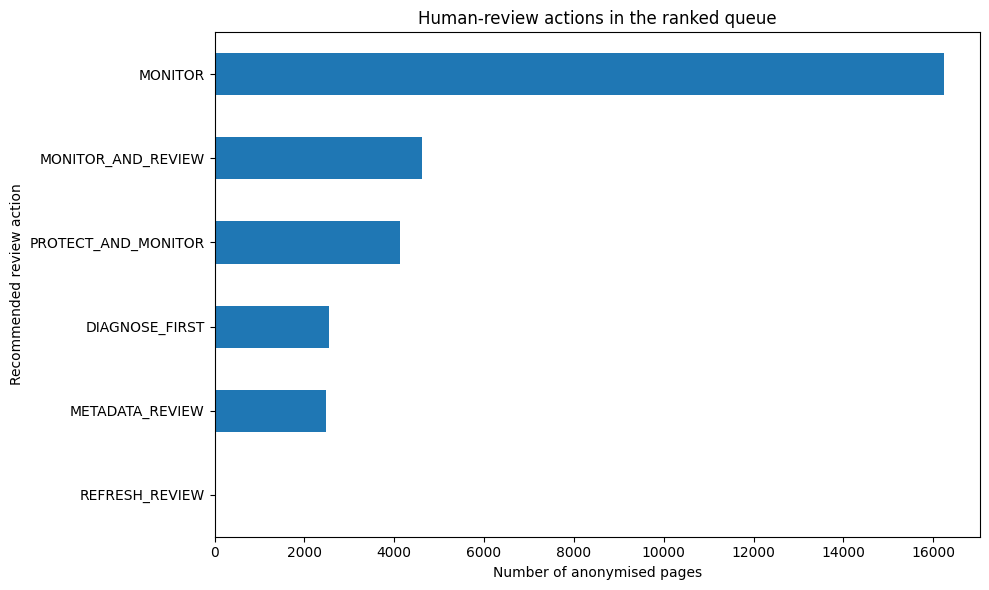

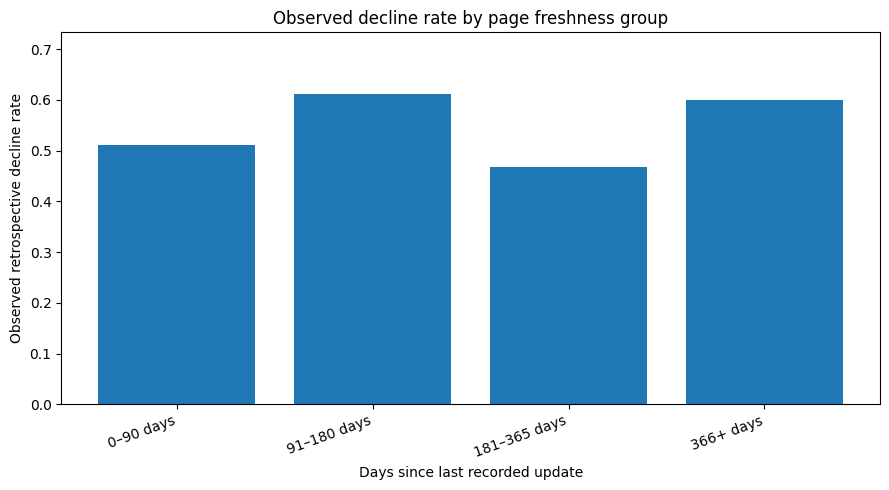

### Export verification

,File,Exists,Commit expectation
0,work/outputs/w07_ranked_action_queue.csv,True,Regenerated; keep out of Git
1,work/outputs/w07_playbook_metrics.json,True,Commit
2,work/figures/w07_action_distribution.png,True,Commit
3,work/figures/w07_decay_refresh_insight.png,True,Commit


All Week-7 exports created successfully.
Queue CSV: /content/flyrank_w07_repo/work/outputs/w07_ranked_action_queue.csv
Metrics JSON: /content/flyrank_w07_repo/work/outputs/w07_playbook_metrics.json
Figures: /content/flyrank_w07_repo/work/figures
Commit-artifact ZIP: /content/w07_commit_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ------------------------------------------------------------

# 5A. Create output directories

# ------------------------------------------------------------

OUTPUT_DIR = (

    REPO_DIR

    / "work"

    / "outputs"

)

FIGURE_DIR = (

    REPO_DIR

    / "work"

    / "figures"

)

OUTPUT_DIR.mkdir(

    parents=True,

    exist_ok=True,

)

FIGURE_DIR.mkdir(

    parents=True,

    exist_ok=True,

)

QUEUE_PATH = (

    OUTPUT_DIR

    / "w07_ranked_action_queue.csv"

)

METRICS_PATH = (

    OUTPUT_DIR

    / "w07_playbook_metrics.json"

)

ACTION_FIGURE_PATH = (

    FIGURE_DIR

    / "w07_action_distribution.png"

)

DECAY_FIGURE_PATH = (

    FIGURE_DIR

    / "w07_decay_refresh_insight.png"

)

# ------------------------------------------------------------

# 5B. Export the regeneratable queue

# ------------------------------------------------------------

queue_export_columns = [

    "queue_rank",

    "content_id",

    "recommended_action",

    "archetype",

    "reason_codes",

    "risk_band",

    "model_risk_score",

    "value_score",

    "review_effort",

    "priority_score",

    "impressions_prev_30d",

    "ctr_prev_30d",

    "avg_position",

    "days_since_last_update",

    "manual_review_required",

    "review_warning",

]

ranked_queue[

    queue_export_columns

].to_csv(

    QUEUE_PATH,

    index=False,

)

# ------------------------------------------------------------

# 5C. Export paper-ready metric receipts

# ------------------------------------------------------------

action_counts = {

    str(action): int(count)

    for action, count in (

        ranked_queue[

            "recommended_action"

        ]

        .value_counts()

        .items()

    )

}

metrics_receipt = {

    "assignment": (

        "ML-10 Content Action Playbook"

    ),

    "lane": (

        "Refresh / Content Opportunity Scoring"

    ),

    "dataset": (

        "FlyRank anonymised starter dataset"

    ),

    "selected_model": selected_model_name,

    "feature_design": (

        "strict pre-outcome previous-30-day features"

    ),

    "validation": {

        "design": (

            "grouped client holdout"

        ),

        "client_overlap": 0,

        "test_rows": int(

            len(test_idx)

        ),

        "test_clients": int(

            len(test_clients)

        ),

        "base_rate": float(

            selected_validation_row[

                "base_rate"

            ]

        ),

        "precision_at_20": float(

            selected_validation_row[

                "precision_at_20"

            ]

        ),

        "precision_at_50": float(

            selected_validation_row[

                "precision_at_50"

            ]

        ),

        "average_precision": float(

            selected_validation_row[

                "average_precision"

            ]

        ),

        "roc_auc": float(

            selected_validation_row[

                "roc_auc"

            ]

        ),

    },

    "queue": {

        "rows": int(

            len(ranked_queue)

        ),

        "high_risk_threshold": float(

            risk_high_threshold

        ),

        "medium_risk_threshold": float(

            risk_medium_threshold

        ),

        "action_counts": action_counts,

        "manual_review_required": True,

        "automatic_content_changes": False,

    },

    "claim_boundary": (

        "Directional decision-support only; "

        "no causal refresh claim."

    ),

}

with open(

    METRICS_PATH,

    "w",

    encoding="utf-8",

) as file:

    json.dump(

        metrics_receipt,

        file,

        indent=2,

    )

# ------------------------------------------------------------

# 5D. Figure: action distribution

# ------------------------------------------------------------

figure_action_counts = (

    ranked_queue[

        "recommended_action"

    ]

    .value_counts()

    .sort_values(

        ascending=True

    )

)

plt.figure(

    figsize=(10, 6)

)

figure_action_counts.plot(

    kind="barh"

)

plt.title(

    "Human-review actions in the ranked queue"

)

plt.xlabel(

    "Number of anonymised pages"

)

plt.ylabel(

    "Recommended review action"

)

plt.tight_layout()

plt.savefig(

    ACTION_FIGURE_PATH,

    dpi=180,

    bbox_inches="tight",

)

plt.show()

# ------------------------------------------------------------

# 5E. Figure: descriptive decay/refresh insight

# ------------------------------------------------------------

plot_decay = (

    decay_refresh_insight

    .dropna(

        subset=[

            "observed_decline_rate"

        ]

    )

    .copy()

)

plt.figure(

    figsize=(9, 5)

)

plt.bar(

    plot_decay[

        "freshness_group"

    ].astype(str),

    plot_decay[

        "observed_decline_rate"

    ],

)

plt.title(

    "Observed decline rate by page freshness group"

)

plt.xlabel(

    "Days since last recorded update"

)

plt.ylabel(

    "Observed retrospective decline rate"

)

plt.xticks(

    rotation=20,

    ha="right",

)

plt.ylim(

    0,

    max(

        0.05,

        float(

            plot_decay[

                "observed_decline_rate"

            ].max()

        )

        * 1.20,

    ),

)

plt.tight_layout()

plt.savefig(

    DECAY_FIGURE_PATH,

    dpi=180,

    bbox_inches="tight",

)

plt.show()

# ------------------------------------------------------------

# 5F. Verify all exports

# ------------------------------------------------------------

export_check = pd.DataFrame(

    [

        {

            "File": str(

                QUEUE_PATH.relative_to(

                    REPO_DIR

                )

            ),

            "Exists": QUEUE_PATH.exists(),

            "Commit expectation": (

                "Regenerated; keep out of Git"

            ),

        },

        {

            "File": str(

                METRICS_PATH.relative_to(

                    REPO_DIR

                )

            ),

            "Exists": METRICS_PATH.exists(),

            "Commit expectation": "Commit",

        },

        {

            "File": str(

                ACTION_FIGURE_PATH.relative_to(

                    REPO_DIR

                )

            ),

            "Exists": (

                ACTION_FIGURE_PATH.exists()

            ),

            "Commit expectation": "Commit",

        },

        {

            "File": str(

                DECAY_FIGURE_PATH.relative_to(

                    REPO_DIR

                )

            ),

            "Exists": (

                DECAY_FIGURE_PATH.exists()

            ),

            "Commit expectation": "Commit",

        },

    ]

)

display(

    Markdown(

        "### Export verification"

    )

)

display(export_check)

assert export_check[

    "Exists"

].all()

# Bundle only the files that should be uploaded to GitHub.

COMMIT_BUNDLE_PATH = (

    Path("/content")

    / "w07_commit_artifacts.zip"

)

import zipfile

with zipfile.ZipFile(

    COMMIT_BUNDLE_PATH,

    "w",

    compression=zipfile.ZIP_DEFLATED,

) as archive:

    archive.write(

        METRICS_PATH,

        arcname=(

            "work/outputs/"

            "w07_playbook_metrics.json"

        ),

    )

    archive.write(

        ACTION_FIGURE_PATH,

        arcname=(

            "work/figures/"

            "w07_action_distribution.png"

        ),

    )

    archive.write(

        DECAY_FIGURE_PATH,

        arcname=(

            "work/figures/"

            "w07_decay_refresh_insight.png"

        ),

    )

print("All Week-7 exports created successfully.")

print(f"Queue CSV: {QUEUE_PATH}")

print(f"Metrics JSON: {METRICS_PATH}")

print(f"Figures: {FIGURE_DIR}")

print(f"Commit-artifact ZIP: {COMMIT_BUNDLE_PATH}")

# Optional Colab download:

try:

    from google.colab import files

    files.download(

        str(COMMIT_BUNDLE_PATH)

    )

except ImportError:

    print(

        "Not running in Colab; automatic download skipped."

    )

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.